# 篇末综合 二室交换与局部近似综合实验

## 学习目标与先修知识

能在同一案例中连接变量与单位、矩阵（matrix）与平衡（equilibrium）、模态（mode）与观测（observation）、局部近似与误差，独立检查结果并限定结论的适用范围。

先修：本篇四章：线性代数（linear algebra）、状态空间（state space）与模态、相平面（phase plane）、局部线性化（linearization）。 [复习上一节](../04-多变量变化与局部线性化/02-线性化能够走多远.ipynb)。

## 具体问题

两个理想组织室共享交换结构。先建立线性清除基线，再将清除改为饱和机制。测总量和测第一室分别能看见什么？局部矩阵的可信范围要用哪些证据支持？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
print('共同交换：a=0.2/T，b=0.1/T；输入仅进入室 1。')
print('线性基线：u=1 U/T，c=0.5/T。')
print('饱和局部实验：u=0.5 U/T，v=1 U/T，K=2 U。')
print('两者平衡均为 [2,4] U，但局部斜率不同；它们不是只改一个参数的因果对照。')

共同交换：a=0.2/T，b=0.1/T；输入仅进入室 1。
线性基线：u=1 U/T，c=0.5/T。
饱和局部实验：u=0.5 U/T，v=1 U/T，K=2 U。
两者平衡均为 [2,4] U，但局部斜率不同；它们不是只改一个参数的因果对照。


## 模型假设

先用开放线性模型（model）核对矩阵与观测，容积 V1=2 L、V2=1 L，平衡浓度（concentration）为 [1,4] U/L。再用封闭模型比较初值（initial condition） [6,0] 的两种观测。最后在饱和模型内仅改变第一室初始扰动 .2 U 或 3 U，保持其他条件相同。

三个子实验分别研究收支（mass balance）、观测和局部近似；各组对照保持固定容积、充分混合及相同清除规则。

## 数学解释与推导

按问题选择核验依据，而非只堆叠计算。

1. **基线收支（mass balance）**：$M=[[-a-c,b],[a,-b]]$，输入（input） [u,0]。全系统只剩 $\dot S=u-cA_1$；平衡应同时满足 $cA_1^*=u$ 和 $aA_1^*=bA_2^*$。容积只进入浓度输出（output），不擅自改变以所追踪物质总量（tracked amount）定义的交换系数。
2. **状态（state）与观测**：封闭例 $A_1=2+4e^{-.3t}$、$A_2=4-4e^{-.3t}$。分配模态的变化方向 [1,−1] 被总量观测 [1,1] 抵消，不能由平直输出断言内部静止。
3. **局部机制**：饱和例 J11=−a−vK/(K+A1*)²=−.325/T。围绕 x* 写 $\dot\delta=J^*\delta$，绝对状态是 x*+δ。把展开点忘掉会改变平衡位置。
4. **数值与模型**：用相同欧拉网格比较原模型、局部模型，再各自减半网格。模型差和网格差需要分别计算，远近平衡条件也要分别报告。

若希望公平比较两种清除机制，还可在同一平衡匹配函数值与一阶斜率（slope），构造仿射（affine）切线（tangent line）清除 $g_{\rm tangent}(A)=g(A^*)+g'(A^*)(A-A^*)$；它与简单的 cA 不总能同时在同一点匹配值和斜率。切线可能在远处失去非负性（nonnegativity），仍只能局部使用。

篇末题组分别检查建模、实现、解释和范围。每个子题都有独立输入，不依赖上一题的提交结果。完成计算以后，继续追问：单位是否一致、所用平衡是否存在、测量是否丢失某种变化、所声称的范围是否真正经过检验。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def open_equilibrium(a, b, c, u):
    first = u/c
    return [first, a*first/b]

def equilibrium_observations(a, b, c, u, volume1, volume2):
    matrix = [[-a-c, b], [a, -b]]
    equilibrium = open_equilibrium(a, b, c, u)
    concentrations = [equilibrium[0]/volume1, equilibrium[1]/volume2]
    return matrix, equilibrium, concentrations
def closed_state(a, b, initial, times):
    import math
    total = sum(initial)
    if a+b == 0:
        return [list(initial) for _ in times]
    states = []
    for t in times:
        remaining = math.exp(-(a+b)*t)
        transferred = -math.expm1(-(a+b)*t)
        states.append([initial[0]*remaining+total*(b/(a+b))*transferred,
                       initial[1]*remaining+total*(a/(a+b))*transferred])
    return states
def nonlinear_rate(state, a, b, u, v, K):
    first, second = state
    return [u-a*first+b*second-v*first/(K+first), a*first-b*second]

def jacobian(state, a, b, v, K):
    slope = v*K/(K+state[0])**2
    return [[-a-slope, b], [a, -b]]

def local_comparison(initial, a, b, u, v, K, h, steps):
    first_star = u*K/(v-u)
    equilibrium = [first_star, a*first_star/b]
    matrix = jacobian(equilibrium, a, b, v, K)
    original, linear = [list(initial)], [list(initial)]
    for _ in range(steps):
        rate = nonlinear_rate(original[-1], a, b, u, v, K)
        delta = [linear[-1][j]-equilibrium[j] for j in range(2)]
        linear_rate = [sum(row[j]*delta[j] for j in range(2)) for row in matrix]
        original.append([original[-1][j]+h*rate[j] for j in range(2)])
        linear.append([linear[-1][j]+h*linear_rate[j] for j in range(2)])
    error = max(abs(x-y) for pair, reference in zip(original, linear) for x, y in zip(pair, reference))
    return original, linear, error

## 对照实验

| 室 | 平衡总量 / U | 平衡浓度 / (U/L) |
| --- | --- | --- |
| 1 | 2 | 1 |
| 2 | 4 | 4 |

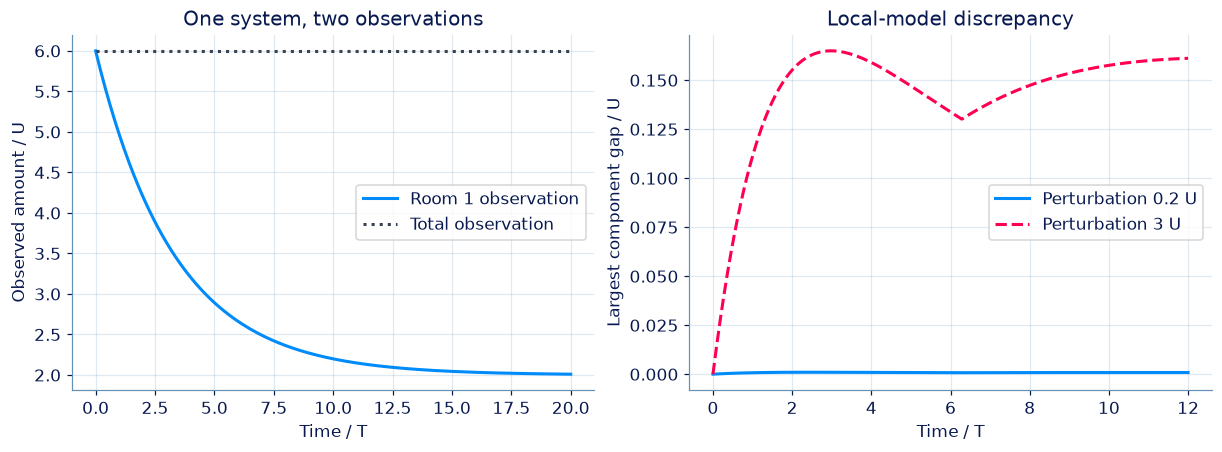

| 初始扰动 / U | 最大模型差 / U |
| --- | --- |
| 0.2 | 0.000992188 |
| 3 | 0.164967 |

In [4]:
matrix,eq,concentration=equilibrium_observations(.2,.1,.5,1,2,1)
display(Markdown(show_table(['室','平衡总量 / U','平衡浓度 / (U/L)'],[(1,eq[0],concentration[0]),(2,eq[1],concentration[1])])))
times=np.linspace(0,20,201);closed=np.array(closed_state(.2,.1,[6,0],times))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(times,closed[:,0],color=BLUE,label='Room 1 observation')
axes[0].plot(times,closed.sum(axis=1),':',color='#384251',label='Total observation')
axes[0].set(xlabel='Time / T',ylabel='Observed amount / U',title='One system, two observations');axes[0].legend()
metrics=[]
for delta,color,style in [(.2,BLUE,'-'),(3,PINK,'--')]:
    original,local,error=local_comparison([2+delta,4],.2,.1,.5,1,2,.01,1200)
    gap=np.max(abs(np.array(original)-local),axis=1)
    axes[1].plot(np.arange(1201)*.01,gap,style,color=color,label=f'Perturbation {delta} U')
    metrics.append((delta,error))
axes[1].set(xlabel='Time / T',ylabel='Largest component gap / U',title='Local-model discrepancy');axes[1].legend();plt.show()
display(Markdown(show_table(['初始扰动 / U','最大模型差 / U'],metrics)))

## 结果解释

封闭观测实验说明看不见不等于不存在；局部实验说明导数（derivative）正确不等于远处预测准确。两个子图各自服务于一个问题，图中的参数（parameter）和单位决定结论范围。

### 独立核对

把各子实验的结果代回收支与观测关系，再比较局部模型和原模型的误差。

In [5]:
np.testing.assert_allclose(np.array(matrix)@eq+[1,0],[0,0],atol=1e-12)
np.testing.assert_allclose(concentration,[1,4])
np.testing.assert_allclose(closed[:,0],2+4*np.exp(-.3*times))
np.testing.assert_allclose(closed.sum(axis=1),6)
assert metrics[1][1]>metrics[0][1]
np.testing.assert_allclose(jacobian([2,4],.2,.1,1,2),[[-.325,.1],[.2,-.1]])
print('基线收支、浓度、独立封闭解与局部矩阵通过；下一步用题组独立完成迁移。')

基线收支、浓度、独立封闭解与局部矩阵通过；下一步用题组独立完成迁移。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：两室状态与浓度观测

两个固定容积的室 V1=2 L、V2=1 L，所追踪物质总量（tracked amount）状态（state）为 [2,4] U。哪一项正确？

- **A.** 状态总量为 6 U，室 1 浓度（concentration）为 1 U/L。
- **B.** 总量为 5 U/L。
- **C.** 两室量之比必定等于浓度之比。
- **D.** 把观测（observation）由总量换成浓度，会自动改变实际交换机制。

[作答：两室状态与浓度观测](http://127.0.0.1:8000/parts/03-%E5%A4%9A%E5%8F%98%E9%87%8F%E7%9B%B8%E4%BA%92%E4%BD%9C%E7%94%A8/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p03-cap-units)

### 第 2 题 · 基础辨析 · 10 分 · 多项选择题：交换与外部损失的区别

M=[[-a-c,b],[a,−b]]，输入（input）为 [u,0] U/T，状态（state）为两室所追踪物质总量（tracked amount）。哪些正确？

- **A.** 第一列的和是 −c。
- **B.** 总变化率为 u−cA1。
- **C.** aA1 和 bA2 都应再从总量扣除。
- **D.** 非对角正项表示来自另一室的接收。

[作答：交换与外部损失的区别](http://127.0.0.1:8000/parts/03-%E5%A4%9A%E5%8F%98%E9%87%8F%E7%9B%B8%E4%BA%92%E4%BD%9C%E7%94%A8/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p03-cap-signs)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：用收支、矩阵和观测互相核对

比较两个固定容积的组织室。室 1 有输入（input） u 和线性清除 cA1，室间交换为 aA1、bA2。返回系统矩阵（matrix）、平衡（equilibrium）所追踪物质总量（tracked amount）与平衡浓度（concentration）；体积只用于观测（observation），不改变题设按总量定义的交换系数。

**函数与代码模板**

```python
def solve(
    a: float,
    b: float,
    c: float,
    u: float,
    volume1: float,
    volume2: float,
) -> tuple[list[list[float]], list[float], list[float]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 室 1 到室 2 的交换系数。 | 1/T |
| `b` | `float` | 室 2 到室 1 的交换系数。 | 1/T |
| `c` | `float` | 仅从室 1 清除的系数。 | 1/T |
| `u` | `float` | 仅进入室 1 的恒定输入速率。 | U/T |
| `volume1` | `float` | 室 1 固定容积。 | L |
| `volume2` | `float` | 室 2 固定容积。 | L |

**返回值**

按以下顺序返回元组：(matrix, equilibrium, concentrations)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 总量状态（state）的 2×2 矩阵。 | 1/T |
| `equilibrium` | `list[float]` | 两个室的平衡总量。 | U |
| `concentrations` | `list[float]` | 两个室的平衡浓度。 | U/L |

**计算规则**

M=[[-a-c,b],[a,-b]]；由 Mx*+[u,0]=0 求平衡；浓度分别为 x1*/volume1、x2*/volume2。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0≤a≤1；0.05≤b,c≤1；0≤u≤5；0.1≤volume1,volume2≤10。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 室 1 到室 2 的交换系数。 | 0.2 | 1/T |
| b | 室 2 到室 1 的交换系数。 | 0.1 | 1/T |
| c | 仅从室 1 清除的系数。 | 0.5 | 1/T |
| u | 仅进入室 1 的恒定输入速率。 | 1 | U/T |
| volume1 | 室 1 固定容积。 | 2 | L |
| volume2 | 室 2 固定容积。 | 1 | L |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.2
b = 0.1
c = 0.5
u = 1
volume1 = 2
volume2 = 1

result = solve(a, b, c, u, volume1, volume2)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | 总量状态（state）的 2×2 矩阵。 | [[-0.7, 0.1], [0.2, -0.1]] | 1/T |
| equilibrium | 两个室的平衡总量。 | [2.0, 4.0] | U |
| concentrations | 两个室的平衡浓度。 | [1.0, 4.0] | U/L |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[-0.7, 0.1], [0.2, -0.1]],
                   [2.0, 4.0],
                   [1.0, 4.0])
```

**样例解释**

平衡总量 [2,4] U；除以 [2,1] L 后浓度为 [1,4] U/L。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：用收支、矩阵和观测互相核对](http://127.0.0.1:8000/parts/03-%E5%A4%9A%E5%8F%98%E9%87%8F%E7%9B%B8%E4%BA%92%E4%BD%9C%E7%94%A8/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p03-integrated-balance)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：初值与观测共同决定可见模态

对称两室 M=[[-a-c,a],[a,−a-c]]，无输入（input），两个室都以 c 清除。观测（observation） y=weights[0]A1+weights[1]A2。计算两个模态（mode）及它们在观测中的逐时贡献，区分没有激发和被观测抵消。

**函数与代码模板**

```python
def solve(
    a: float,
    c: float,
    initial: list[float],
    weights: list[float],
    times: list[float],
) -> tuple[list[float], list[float], list[list[float]], list[list[float]]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 双向交换系数。 | 1/T |
| `c` | `float` | 每室清除系数（elimination rate constant）。 | 1/T |
| `initial` | `list[float]` | 起始两室所追踪物质总量（tracked amount）。 | U |
| `weights` | `list[float]` | 两个观测权重。 | 1 |
| `times` | `list[float]` | 所求时刻。 | T |

**返回值**

按以下顺序返回元组：(eigenvalues, coefficients, states, contributions)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `eigenvalues` | `list[float]` | 共同、差异模态顺序。 | 1/T |
| `coefficients` | `list[float]` | 未归一化 [1,1]、[1,−1] 的初值（initial condition）系数。 | U |
| `states` | `list[list[float]]` | 每个时刻 [A1,A2]。 | U |
| `contributions` | `list[list[float]]` | 每行分别为共同模态、差异模态对 y 的贡献，两项之和等于 y。 | U |

**计算规则**

共同模态特征值（eigenvalue） −c，差异模态 −(2a+c)。先把 initial 分解到 [1,1] 和 [1,−1]，再分别传播，并分别乘观测权重与该方向的内积（inner product）；输出（output）顺序固定。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0.05≤a≤1；0≤c≤1；initial 长度 2，分量 0—20；weights 长度 2，分量绝对值≤2；times 长度 1—20，0≤t≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 双向交换系数。 | 0.2 | 1/T |
| c | 每室清除系数（elimination rate constant）。 | 0.1 | 1/T |
| initial | 起始两室所追踪物质总量（tracked amount）。 | [6, 0] | U |
| weights | 两个观测权重。 | [1, 1] | 1 |
| times | 所求时刻。 | [0, 2] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.2
c = 0.1
initial = [6, 0]
weights = [1, 1]
times = [0, 2]

result = solve(a, c, initial, weights, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| eigenvalues | 共同、差异模态顺序。 | [-0.1, -0.5] | 1/T |
| coefficients | 未归一化 [1,1]、[1,−1] 的初值（initial condition）系数。 | [3.0, 3.0] | U |
| states | 每个时刻 [A1,A2]。 | [[6.0, 0.0], [3.5598305827482726, 1.3525539357196186]] | U |
| contributions | 每行分别为共同模态、差异模态对 y 的贡献，两项之和等于 y。 | [[6.0, 0.0], [4.912384518467891, 0.0]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-0.1, -0.5],
                   [3.0, 3.0],
                   [[6.0, 0.0],
                    [3.5598305827482726,
                     1.3525539357196186]],
                   [[6.0, 0.0], [4.912384518467891, 0.0]])
```

**样例解释**

初值系数 [3,3] U，两个模态都被激发；总量观测 weights=[1,1] 把差异模态抵消，t=0 的两项观测贡献为 [6,0] U。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：初值与观测共同决定可见模态](http://127.0.0.1:8000/parts/03-%E5%A4%9A%E5%8F%98%E9%87%8F%E7%9B%B8%E4%BA%92%E4%BD%9C%E7%94%A8/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p03-cap-modes)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：连接方向平衡与固定时刻

封闭交换 a,b≥0 且 a+b>0，整个向量场（vector field）再乘正倍率 multiplier。给定完整初值（initial condition），计算起点方向、该守恒总量选定的平衡（equilibrium），以及指定时刻的状态（state）。

**函数与代码模板**

```python
def solve(
    a: float,
    b: float,
    initial: list[float],
    times: list[float],
    multiplier: float,
) -> tuple[list[float], list[float], list[list[float]]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 室 1 到室 2 的交换系数。 | 1/T |
| `b` | `float` | 室 2 到室 1 的交换系数。 | 1/T |
| `initial` | `list[float]` | 起始 [A1,A2]。 | U |
| `times` | `list[float]` | 指定观察时刻。 | T |
| `multiplier` | `float` | 两个交换方向的共同倍率。 | 1 |

**返回值**

按以下顺序返回元组：(rate, equilibrium, states)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rate` | `list[float]` | 乘倍率后的起点变化率。 | U/T |
| `equilibrium` | `list[float]` | 当前总量对应的平衡，不是有限时刻的末量。 | U |
| `states` | `list[list[float]]` | 每个观察时刻的 [A1,A2]。 | U |

**计算规则**

内部交换守恒；平衡满足 aA1*=bA2*。倍率作用于两个变化率；用第 3.3 章闭式传播在 times 指定的时刻求解，不作欧拉近似。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 0≤a,b≤1，a+b≥0.05；initial 长度 2，各分量 0—20；0.1≤multiplier≤3；times 长度 1—20，0≤t≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 室 1 到室 2 的交换系数。 | 0.2 | 1/T |
| b | 室 2 到室 1 的交换系数。 | 0.1 | 1/T |
| initial | 起始 [A1,A2]。 | [6, 0] | U |
| times | 指定观察时刻。 | [0, 1] | T |
| multiplier | 两个交换方向的共同倍率。 | 2 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.2
b = 0.1
initial = [6, 0]
times = [0, 1]
multiplier = 2

result = solve(a, b, initial, times, multiplier)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rate | 乘倍率后的起点变化率。 | [-2.4000000000000004, 2.4000000000000004] | U/T |
| equilibrium | 当前总量对应的平衡，不是有限时刻的末量。 | [2.0, 4.0] | U |
| states | 每个观察时刻的 [A1,A2]。 | [[6.0, 0.0], [4.195246544376105, 1.8047534556238942]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-2.4000000000000004,
                    2.4000000000000004],
                   [2.0, 4.0],
                   [[6.0, 0.0],
                    [4.195246544376105,
                     1.8047534556238942]])
```

**样例解释**

起点方向从 [−1.2,1.2] 加倍为 [−2.4,2.4] U/T；平衡仍为 [2,4]，t=1 对应未加倍模型（model） t=2 的状态。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：连接方向平衡与固定时刻](http://127.0.0.1:8000/parts/03-%E5%A4%9A%E5%8F%98%E9%87%8F%E7%9B%B8%E4%BA%92%E4%BD%9C%E7%94%A8/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p03-cap-phase)

### 第 6 题 · 综合验证 · 15 分 · 多项选择题：总量观测下看不见的运动

封闭交换 a=.2/T、b=.1/T，初值（initial condition） [6,0]。记录 y1=A1、y2=A1+A2。哪些正确？

- **A.** y2 一直为 6 U。
- **B.** y1 从 6 向 2 U 靠近。
- **C.** y2 不变说明两个室都没有运动。
- **D.** 从初值和平衡（equilibrium）的差 [4,−4] 可看出被总量观测（observation）抵消的变化方向。

[作答：总量观测下看不见的运动](http://127.0.0.1:8000/parts/03-%E5%A4%9A%E5%8F%98%E9%87%8F%E7%9B%B8%E4%BA%92%E4%BD%9C%E7%94%A8/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p03-integrated-output)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：分开模型差与步长差

饱和两室 f1=u−aA1+bA2−vA1/(K+A1)，f2=aA1−bA2。给定若干初始所追踪物质总量（tracked amount），用平衡（equilibrium）处同一 雅可比矩阵（Jacobian matrix） 比较原模型（model）和局部模型，并分别用半步长复算。

**函数与代码模板**

```python
def solve(
    initials: list[list[float]],
    a: float,
    b: float,
    u: float,
    v: float,
    K: float,
    h: float,
    steps: int,
) -> tuple[list[list[float]], list[float], list[float]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initials` | `list[list[float]]` | 各行一组非负初值（initial condition）；各组独立实验。 | U |
| `a` | `float` | 室 1 到室 2 的交换系数。 | 1/T |
| `b` | `float` | 室 2 到室 1 的交换系数。 | 1/T |
| `u` | `float` | 进入室 1 的输入（input）速率。 | U/T |
| `v` | `float` | 室 1 饱和清除的最大速率。 | U/T |
| `K` | `float` | 清除速率达到 v/2 时的总量。 | U |
| `h` | `float` | 粗网格欧拉步长。 | T |
| `steps` | `int` | 粗网格更新次数，细网格做两倍次数，终点相同。 | 步 |

**返回值**

按以下顺序返回元组：(matrix, model_errors, grid_differences)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 平衡处 雅可比矩阵。 | 1/T |
| `model_errors` | `list[float]` | 每组粗网格原模型与局部模型的最大分量差。 | U |
| `grid_differences` | `list[float]` | 每组两种模型各自粗细对照的最大分量差，再在两种模型间取最大值。 | U |

**计算规则**

平衡 x*=[uK/(v−u),a uK/(b(v−u))]。粗网格各自用 x←x+h*f(x)、z←z+h*J(x*)*(z−x*)，两者都从该组初值出发。细网格 h/2 做 2*steps 次；只在与粗网格相同的时刻（细网格偶数下标）比较。各最大值包含起点、所有观察时刻与两个分量，不返回轨迹（trajectory）。

**约束与边界**

- 所有数值有限；不修改输入列表。
- initials 有 1—4 行，每行 2 个 0—10 的数；0.1≤a,b≤0.5；0.1≤u≤0.5；1≤v,K≤2；0<h≤0.05；0≤steps≤400。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initials | 各行一组非负初值（initial condition）；各组独立实验。 | [[2.2, 4], [5, 4]] | U |
| a | 室 1 到室 2 的交换系数。 | 0.2 | 1/T |
| b | 室 2 到室 1 的交换系数。 | 0.1 | 1/T |
| u | 进入室 1 的输入（input）速率。 | 0.5 | U/T |
| v | 室 1 饱和清除的最大速率。 | 1 | U/T |
| K | 清除速率达到 v/2 时的总量。 | 2 | U |
| h | 粗网格欧拉步长。 | 0.05 | T |
| steps | 粗网格更新次数，细网格做两倍次数，终点相同。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initials = [[2.2, 4], [5, 4]]
a = 0.2
b = 0.1
u = 0.5
v = 1
K = 2
h = 0.05
steps = 2

result = solve(initials, a, b, u, v, K, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | 平衡处 雅可比矩阵。 | [[-0.325, 0.1], [0.2, -0.1]] | 1/T |
| model_errors | 每组粗网格原模型与局部模型的最大分量差。 | [0.00011624023037004605, 0.015769960415719986] | U |
| grid_differences | 每组两种模型各自粗细对照的最大分量差，再在两种模型间取最大值。 | [3.079116360460432e-05, 0.00046186745407261753] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[-0.325, 0.1], [0.2, -0.1]],
                   [0.00011624023037004605,
                    0.015769960415719986],
                   [3.079116360460432e-05,
                    0.00046186745407261753])
```

**样例解释**

两组共用平衡 [2,4] 和 J=[[-0.325,0.1],[0.2,−0.1]]。两步的粗轨迹与四步细轨迹在 t=0、0.05、0.1 对齐，分别求模型差和步长差。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：分开模型差与步长差](http://127.0.0.1:8000/parts/03-%E5%A4%9A%E5%8F%98%E9%87%8F%E7%9B%B8%E4%BA%92%E4%BD%9C%E7%94%A8/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p03-cap-local)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：误差表支持怎样的范围

某饱和模型（model）在相同 12 T 窗口内，近、远扰动的原模型与局部模型最大差分别为 0.004 U、0.55 U；两组的粗细网格差均小于各自模型差的 5%。这些是给定对照结果。若允许模型差不超过 0.01 U，哪些判断合理？

- **A.** 近扰动在本次窗口和误差标准下通过。
- **B.** 远扰动在此标准下不通过。
- **C.** 这些结果足以证明所有初值（initial condition）和任意时长都适用。
- **D.** 主要差异不太可能仅由当前估计的网格误差解释，但仍须限制在已检查条件内。

[作答：误差表支持怎样的范围](http://127.0.0.1:8000/parts/03-%E5%A4%9A%E5%8F%98%E9%87%8F%E7%9B%B8%E4%BA%92%E4%BD%9C%E7%94%A8/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p03-cap-scope)

**进一步阅读**

[Boyd 与 Vandenberghe：应用线性代数](https://web.stanford.edu/~boyd/vmls/)：向量、范数、独立性与线性方程。 [MIT 一阶系统课程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-iv-first-order-systems/)：矩阵方法、矩阵指数、相图与线性化。